<p align="center">
  <img src="fig/wrfhydro_logo.png" alt="WRF-Hydro Logo" width="15%">
  &nbsp;&nbsp;&nbsp; <!-- adds horizontal space -->
  <img src="fig/Coupling_preparation.png" alt="Coupling Preparation" width="70%">
</p>

# WRF-Hydro/MODFLOW Domain Setup: Step 1 — WRF-Hydro Preparation

This Python notebook defines and creates the case-specific model domain and initial conditions for WRF-Hydro components using the **WRF Preprocessing System (WPS)**.

## Authors

**First Version:** Built upon WRF-Hydro Tutorial  

**Created by:** Farshid Felfelani  
Research Applications Laboratory, NSF National Center for Atmospheric Research  

- **Email:** felfelan@ucar.edu

---

## Software Dependencies

This workflow requires the following software:

* **WPS** built with the GNU compilers  
* **R environment** including all libraries needed for running `create_wrfinput` and `create_soilproperties` scripts  
* **WPS geographical input data** for the contiguous United States  

---

## Conda Environment Prerequisite

**[WRF-Hydro Tools](https://github.com/NCAR/wrf_hydro_gis_preprocessor/tree/master)**

* conda config --add channels conda-forge
* conda create -n wrfh_gis_env -c conda-forge python=3.10 gdal netCDF4 numpy pyproj whitebox=2.3.5 packaging shapely xarray ipykernel matplotlib r-base
* conda activate wrfh_gis_env

Installing R packages

* conda install r-optparse
* conda install -c conda-forge r-devtools r-terra r-raster
* conda install -c conda-forge nco cartopy

and within R:
Type in treminal:

R

*** install.packages("getopt", repos='http://cran.us.r-project.org')

*** install.packages("optparse", repos='http://cran.us.r-project.org')

*** install.packages("ncdf4", repos='http://cran.us.r-project.org')

*** devtools::install_github("NCAR/rwrfhydro")

## 1. Bonus Information

### 1.1 Defining the Model Domain and Creating the Geogrid File

WRF-Hydro leverages the powerful **domain generation** and **geophysical dataset processing tools** available in the [WRF Preprocessing System (WPS)](http://www2.mmm.ucar.edu/wrf/users/) to define model domains and generate input files for the land surface model.  

In particular, WRF-Hydro requires:
- a **geogrid file** (generated by WPS utilities), and  
- a **wrfinput file**, created either from WRF itself or from utility scripts provided by the WRF-Hydro team.

This Notebook walks users through the process of **manually creating a geogrid file** using an existing WPS installation and **generating wrfinput files** from provided Python and R script packages.  

---

### 1.2 Data Sources

The **WPS geographical input data**—including *land cover*, *soil texture*, and *terrain height*—are essential datasets used by WRF-Hydro.  
The full dataset collection can be obtained from the [WPS geographical data download page](https://www2.mmm.ucar.edu/wrf/users/download/get_sources_wps_geog.html).  

However, the complete dataset is quite large (~50 GB) and includes many layers not commonly used in most WRF-Hydro implementations.

---

### 1.3 WPS Geogrid

The WPS program **`geogrid.exe`** creates the file **`geo_em.d01.nc`**, hereafter referred to as the *geogrid file*.  
`geogrid.exe` takes as input:

- a **Fortran namelist** (`namelist.wps`) defining the projection, resolution, and spatial extent of the model domain,  
- the desired **input fields**, and  
- the **[WPS geographical input data](http://www2.mmm.ucar.edu/wrf/users/download/get_sources_wps_geog.html)**.  

The output of this process is the **geogrid file**, which defines the spatial framework for the WRF-Hydro land surface model.

---

### 1.4 Defining Domain Boundaries

The **land surface model (LSM)** in WRF-Hydro operates on the domain defined within the geogrid file.  
`geogrid.exe` generates this file based on parameters specified in **`namelist.wps`**.  

The first step in creating the geogrid file is to **define the model domain boundaries**.  
By default, `geogrid.exe` uses a **domain center point** (latitude and longitude), grid spacing, and projection settings to compute the bounding box for the domain.  

If you do not already have these coordinates, you can obtain them from **Google Earth** or a **GIS system**.  
You can also use the **WRF-Hydro geogrid Python command-line utility** to visualize the domain location and create the geogrid file accordingly.

---

### 1.5 Exploring the WPS Geogrid Utility

The **`geogrid.exe`** utility is controlled by settings in the **`namelist.wps`** file.  
While `namelist.wps` includes many options—some of which apply only to the full WRF atmospheric model—only a subset is relevant for WRF-Hydro applications.  

For educational purposes, this tutorial will first examine a **complete `namelist.wps` file**, and then discuss the **key parameters** required by the WRF-Hydro geogrid utility in greater detail.


## 2. Setup the directory and libraries 

First, we need to create a directory to hold the inputs and outputs.

In [1]:
import os
import pathlib
import shutil
import numpy as np
import xarray as xr
import subprocess, sys
import matplotlib.pyplot as plt

from pyproj import Geod

project_root = os.path.join("path-directory",
                            "wrfhydro_cutout")
dxdy = 250
version = "01"
case = "repub"
# case = "drb"

tag = case + "_" + str(dxdy) + "m" + "_v" + version

class _Paths():

    def __init__(self, project_root, tag, dxdy):
        """This class maps several attributes to files of interest in the directory structure and simplifies file access."""

        wps_dir = os.path.join(project_root, tag)
        geo_dir = os.path.join(project_root, tag, 'geogrid')
        dom_dir = os.path.join(project_root, tag, 'DOMAIN')

        # For convenience - make all the local variables (i.e., within the scope of this instance) class attributes.
        self.__dict__.update({k: v for k, v in locals().items() if k != 'self'})

        return

Paths = _Paths(project_root=project_root, tag=tag, dxdy=dxdy)

In [ ]:
Paths.geo_dir

In [3]:
# removing the old stuff if exits
if os.path.isdir(os.path.join(project_root, tag)):
    shutil.rmtree(os.path.join(project_root, tag))

pathlib.Path(Paths.geo_dir).mkdir(parents=True, exist_ok=True)

In [4]:
%%bash

module load conda
conda activate r-4.3

which Rscript

/glade/u/apps/opt/conda/envs/r-4.3/bin/Rscript


### 2.1. Modifying the WPS namelist
**View the WPS namelist** 
    
a sample `namelist.wps` file for the domain of interest

In [5]:
os.chdir(Paths.wps_dir)

In [ ]:
!pwd

In [7]:
%%bash

#r"""
#If we do this copy, we need to modify based on our domain
#"""

cp ./namelist.wps ./namelist.wps


cat namelist.wps

&share
 wrf_core = 'ARW',
 max_dom = 1,
 start_date = '2019-09-04_12:00:00','2019-09-04_12:00:00',
 end_date   = '2019-09-06_00:00:00','2019-09-04_12:00:00',
 interval_seconds = 10800
 io_form_geogrid = 2,
 opt_output_from_geogrid_path = './geogrid',
 debug_level = 0
/

&geogrid
 parent_id         =   1,
 parent_grid_ratio =   1,
 i_parent_start    =   1,
 j_parent_start    =   1,
 e_we              =  2376,
 e_sn              =  976,
 geog_data_res = 'SRTM_topo_3s+nlcd2011_30m+usgs_30s+soilgrids_250m+landuse_30s+30s+urbfrac_nlcd2011+default',
 dx        = 250.0,
 dy        = 250.0,
 map_proj  = 'lambert',
 ref_lat   =  40.01737867,
 ref_lon   = -100.33816405,
 ref_x     =  1188,
 ref_y     =  488,
 truelat1  =  29.5,
 truelat2  =  45.5,
 stand_lon = -96.0,
 geog_data_path = '/glade/u/home/ksampson/WPS/geog',
 opt_geogrid_tbl_path = './geogrid'
/

&ungrib
 out_format = 'WPS',
 prefix = 'FILE',
/

&metgrid
 fg_name = 'FILE'
/

In [8]:
subprocess.run("yes | cp -rf " + os.path.join("..", "namelist.wps.{0}.bak".format(case)) + " ./namelist.wps", shell=True)

CompletedProcess(args='yes | cp -rf ../namelist.wps.repub.bak ./namelist.wps', returncode=0)

In [9]:
%%bash

# yes | cp -rf ../namelist.wps.bak ./namelist.wps

cat namelist.wps

&share
 wrf_core = 'ARW',
 max_dom = 1,
 start_date = '2019-09-04_12:00:00','2019-09-04_12:00:00',
 end_date   = '2019-09-06_00:00:00','2019-09-04_12:00:00',
 interval_seconds = 10800
 io_form_geogrid = 2,
 opt_output_from_geogrid_path = './geogrid',
 debug_level = 0
/

&geogrid
 parent_id         =   1,
 parent_grid_ratio =   1,
 i_parent_start    =   1,
 j_parent_start    =   1,
 e_we              =  2376,
 e_sn              =  976,
 geog_data_res = 'SRTM_topo_3s+nlcd2011_30m+usgs_30s+soilgrids_250m+landuse_30s+30s+urbfrac_nlcd2011+default',
 dx        = 250.0,
 dy        = 250.0,
 map_proj  = 'lambert',
 ref_lat   =  40.01737867,
 ref_lon   = -100.33816405,
 ref_x     =  1188,
 ref_y     =  488,
 truelat1  =  29.5,
 truelat2  =  45.5,
 stand_lon = -96.0,
 geog_data_path = '/glade/u/home/ksampson/WPS/geog',
 opt_geogrid_tbl_path = './geogrid'
/

&ungrib
 out_format = 'WPS',
 prefix = 'FILE',
/

&metgrid
 fg_name = 'FILE'
/

In [ ]:
Paths.wps_dir

A full description of these options can be found in the [WPS User Guide](https://www2.mmm.ucar.edu/wrf/users/docs/user_guide_v4/v4.2/users_guide_chap3.html). 

The options that are of interest to most WRF-Hydro users are the following:

**Table 1. WPS namelist options relevent to WRF-Hydro**

|Option|Description|
|------|-----------|
| e_we | The number of grid edges in the west-east dimension. The number of grid centers will be e_we-1. |
| e_sn | The number of grid edges in the south-north dimension. The number of grid centers will be e_sn-1. |
| ref_lat | A real value specifying the latitude part of a (latitude, longitude) center-point of the domain. |
| ref_lon | A real value specifying the longitude part of a (latitude, longitude) center-point of the domain. West longitudes are negative, and the value of ref_lon should be in the range [-180, 180]. |
| dx | A real value specifying the grid distance in the x-direction where the map scale factor is 1. The grid distance is in meters for the 'polar', 'lambert', and 'mercator' projection, and in degrees longitude for the 'lat-lon' projection. |
| dy | A real value specifying the grid distance in the y-direction where the map scale factor is 1. The grid distance is in meters for the 'polar', 'lambert', and 'mercator' projection, and in degrees latitude for the 'lat-lon' projection. |
| map_proj | A character string specifying the projection of the simulation domain. Accepted projections are 'lambert', 'polar', 'mercator', and 'lat-lon'. Default value is 'lambert'. |
| truelat1 | A real value specifying, the first true latitude for the Lambert conformal conic projection, or the only true latitude for the Mercator and polar stereographic projections. |
| truelat2 | A real value specifying, the second true latitude for the Lambert conformal conic projection. For all other projections, truelat2 is ignored. No default value. |
| stand_lon | A real value specifying, the longitude that is parallel with the y-axis in the Lambert conformal and polar stereographic projections. For the regular latitude-longitude projection, this value gives the rotation about the earth's geographic poles. No default value. |
| geog_data_res | A character string specifying a corresponding resolution or list of resolutions separated by + symbols of source data to be used when interpolating static terrestrial data to the grid. This string should contain a resolution matching a string preceding a colon in a rel_path or abs_path specification (see the description of GEOGRID.TBL options) in the GEOGRID.TBL file for each field. If a resolution in the string does not match any such string in a rel_path or abs_path specification for a field in GEOGRID.TBL, a default resolution of data for that field, if one is specified, will be used. If multiple resolutions match, the first resolution to match a string in a rel_path or abs_path specification in the GEOGRID.TBL file will be used. Default value is 'default'. |
| geog_data_path | A character string giving the path, either relative or absolute, to the directory where the geographical data directories may be found. This path is the one to which rel_path specifications in the GEOGRID.TBL file are given in relation to. No default value. |

### 2.2. Creating the geogrid file
In this section, we will create the geogrid file using the WPS geogrid utility. 

In [12]:
%%bash

echo $LD_LIBRARY_PATH

module list

/glade/u/apps/casper/23.10/spack/opt/spack/openmpi/4.1.6/oneapi/2023.2.1/dgcv/lib:/glade/u/apps/common/23.08/spack/opt/spack/cuda/12.2.1/lib64:/glade/u/apps/common/23.08/spack/opt/spack/cuda/12.2.1/nvvm/lib64:/glade/u/apps/common/23.08/spack/opt/spack/cuda/12.2.1/extras/CUPTI/lib64:/glade/u/apps/common/23.08/spack/opt/spack/cuda/12.2.1/extras/Debugger/lib64:/glade/u/apps/common/23.08/spack/opt/spack/intel-oneapi-compilers/2023.2.1/compiler/2023.2.1/linux/lib:/glade/u/apps/common/23.08/spack/opt/spack/intel-oneapi-compilers/2023.2.1/compiler/2023.2.1/linux/lib/x64:/glade/u/apps/common/23.08/spack/opt/spack/intel-oneapi-compilers/2023.2.1/compiler/2023.2.1/linux/lib/oclfpga/host/linux64/lib:/glade/u/apps/common/23.08/spack/opt/spack/intel-oneapi-compilers/2023.2.1/compiler/2023.2.1/linux/compiler/lib/intel64_lin:/glade/u/apps/casper/23.10/spack/opt/spack/hdf5/1.12.2/oneapi/2023.2.1/6vf2/lib



Currently Loaded Modules:
  1) ncarenv/23.10       (S)   4) cuda/12.2.1     7) hdf5/1.12.2
  2) intel/2023.2.1            5) ucx/1.14.1      8) netcdf/4.9.2
  3) ncarcompilers/1.0.0       6) openmpi/4.1.6   9) texlive/20220321

  Where:
   S:  Module is Sticky, requires --force to unload or purge

 



In [13]:
os.chdir(Paths.wps_dir)

In [15]:
%%bash

cp ./WPS/WPSV4.4_intel_serial_large-file/geogrid/*.exe geogrid
cp ./WPS/WPSV4.4_intel_serial_large-file/NGM/GEOGRID.TBL geogrid/GEOGRID.TBL

In [16]:
%%bash
pwd

./geogrid/geogrid.exe

/glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/wrfhydro_cutout/repub_250m_v01
Parsed 48 entries in GEOGRID.TBL
Processing domain 1 of 1
  Processing XLAT and XLONG
  Processing MAPFAC
  Processing F and E
  Processing ROTANG
  Processing LANDUSEF
  Calculating landmask from LANDUSEF ( WATER =  16 )
  Processing HGT_M
  Processing SOILTEMP
  Processing SOILCTOP
  Processing SCT_DOM
  Processing SOILCBOT
  Processing SCB_DOM
  Processing ALBEDO12M
  Processing GREENFRAC
  Processing LAI12M
  Processing SNOALB
  Processing CON
  Processing VAR
  Processing OA1
  Processing OA2
  Processing OA3
  Processing OA4
  Processing OL1
  Processing OL2
  Processing OL3
  Processing OL4
  Processing VAR_SSO
  Processing LAKE_DEPTH
  Processing IMPERV
  Processing CANFRA
  Processing EROD
  Processing CLAYFRAC
  Processing SANDFRAC
  Processing IRRIGATION
  Processing CONLS
  Processing VARLS
  Processing OA1LS
  Processing OA2LS
  Processing OA3LS
  Processing OA4L

#### Inspecting the geogrid file
Now that we have created our geogrid file, we will quickly display the file header using the *ncdump* command line utility and open the file using the Python library `xarray` to visualize its contents. 

In [17]:
%%bash

ncdump -h ./geogrid/geo_em.d01.nc

netcdf geo_em.d01 {
dimensions:
	Time = UNLIMITED ; // (1 currently)
	DateStrLen = 19 ;
	west_east = 2375 ;
	south_north = 975 ;
	south_north_stag = 976 ;
	west_east_stag = 2376 ;
	land_cat = 24 ;
	soil_cat = 16 ;
	month = 12 ;
	dust_erosion_dimension = 3 ;
variables:
	char Times(Time, DateStrLen) ;
	float XLAT_M(Time, south_north, west_east) ;
		XLAT_M:FieldType = 104 ;
		XLAT_M:MemoryOrder = "XY " ;
		XLAT_M:units = "degrees latitude" ;
		XLAT_M:description = "Latitude on mass grid" ;
		XLAT_M:stagger = "M" ;
		XLAT_M:sr_x = 1 ;
		XLAT_M:sr_y = 1 ;
	float XLONG_M(Time, south_north, west_east) ;
		XLONG_M:FieldType = 104 ;
		XLONG_M:MemoryOrder = "XY " ;
		XLONG_M:units = "degrees longitude" ;
		XLONG_M:description = "Longitude on mass grid" ;
		XLONG_M:stagger = "M" ;
		XLONG_M:sr_x = 1 ;
		XLONG_M:sr_y = 1 ;
	float XLAT_V(Time, south_north_stag, west_east) ;
		XLAT_V:FieldType = 104 ;
		XLAT_V:MemoryOrder = "XY " ;
		XLAT_V:units = "degrees latitude" ;
		XLAT_V:description = "Latitu

In [18]:
xr.set_options(display_style="html")
ds = xr.open_dataset('./geogrid/geo_em.d01.nc')

ds

<xarray.Dataset> Size: 2GB
Dimensions:     (Time: 1, south_north: 975, west_east: 2375,
                 south_north_stag: 976, west_east_stag: 2376, land_cat: 24,
                 soil_cat: 16, month: 12, dust_erosion_dimension: 3)
Dimensions without coordinates: Time, south_north, west_east, south_north_stag,
                                west_east_stag, land_cat, soil_cat, month,
                                dust_erosion_dimension
Data variables: (12/80)
    Times       (Time) |S19 19B ...
    XLAT_M      (Time, south_north, west_east) float32 9MB ...
    XLONG_M     (Time, south_north, west_east) float32 9MB ...
    XLAT_V      (Time, south_north_stag, west_east) float32 9MB ...
    XLONG_V     (Time, south_north_stag, west_east) float32 9MB ...
    XLAT_U      (Time, south_north, west_east_stag) float32 9MB ...
    ...          ...
    OA4SS       (Time, south_north, west_east) float32 9MB ...
    OL1SS       (Time, south_north, west_east) float32 9MB ...
    OL2SS       (Time, south_north, west_east) float32 9MB ...
    OL3SS       (Time, south_north, west_east) float32 9MB ...
    OL4SS       (Time, south_north, west_east) float32 9MB ...
    BATHYMETRY  (Time, south_north, west_east) float32 9MB ...
Attributes: (12/54)
    TITLE:                           OUTPUT FROM GEOGRID V4.4
    SIMULATION_START_DATE:           0000-00-00_00:00:00
    WEST-EAST_GRID_DIMENSION:        2376
    SOUTH-NORTH_GRID_DIMENSION:      976
    BOTTOM-TOP_GRID_DIMENSION:       0
    WEST-EAST_PATCH_START_UNSTAG:    1
    ...                              ...
    FLAG_IMPERV:                     1
    FLAG_CANFRA:                     1
    FLAG_EROD:                       1
    FLAG_CLAYFRAC:                   1
    FLAG_SANDFRAC:                   1
    FLAG_BATHYMETRY:                 1

### 2.3. Create domain boundary shapefile and raster

In [25]:
# Set root directory for GIS lesson
gis_data_folder = Paths.wps_dir

# Change the directory to the GIS_Training directory and get current working directory
os.chdir(gis_data_folder)
cwd = os.getcwd()

# Set paths to known input and output directories and files
data_folder = os.path.join(cwd)
in_geogrid = os.path.join(Paths.geo_dir, 'geo_em.d01.nc')
output_folder = os.path.join(cwd, 'Outputs')

# Clear any outputs from previous runs by deleting (if necessary) and re-creating the output directory
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)
os.mkdir(output_folder)

In [26]:
os.chdir("./wrf_hydro_gis_preprocessor/wrfhydro_gis")

# Adding the path to WRF_Hydro Functions
# try:
#     from wrfhydro_functions import WRF_Hydro_Grid
# except:
#     sys.path.append(r'./wrf_hydro_gis_preprocessor/wrfhydro_gis')
#     from wrfhydro_functions import WRF_Hydro_Grid

# Execute script on the command-line, requesting tool help (parameter -h)
! python Create_Domain_Boundary_Shapefile.py -h

Script initiated at Fri Sep 27 13:14:58 2024
usage: Create_Domain_Boundary_Shapefile.py [-h] -i IN_NC -o OUT_DIR

This tool takes an WRF Geogrid file and creates a single polygon shapefile
that makes up the boundary of the domain of the M-grid (HGT_M, for example).

options:
  -h, --help  show this help message and exit
  -i IN_NC    Path to WPS geogrid (geo_em.d0*.nc) file or WRF-Hydro
              Fulldom_hires.nc file.
  -o OUT_DIR  Output directory.


In [27]:
# Print information to screen for reference
print('Command to run:\n')
print('python Create_Domain_Boundary_Shapefile.py \\\n\t -i {0} \\\n\t -o {1}\n'.format(in_geogrid, output_folder))

# Run the script with required parameters
! python Create_Domain_Boundary_Shapefile.py -i {in_geogrid} -o {output_folder}

Command to run:

python Create_Domain_Boundary_Shapefile.py \
	 -i /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/wrfhydro_cutout/repub_250m_v01/geogrid/geo_em.d01.nc \
	 -o /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/wrfhydro_cutout/repub_250m_v01/Outputs

Script initiated at Fri Sep 27 13:14:58 2024
    WPS netCDF projection identification initiated...
    Map Projection: Lambert Conformal Conic
    Using MOAD_CEN_LAT for latitude of origin.
    Using Standard Parallel 2 in Lambert Conformal Conic map projection.
    Geo-referencing step completed without error in  0.02 seconds.
    Created projection definition from input NetCDF GEOGRID file.
      ESRI Shapefile driver is available.
Traceback (most recent call last):
  File "/glade/u/home/ksampson/wrf_hydro_gis_preprocessor/wrfhydro_gis/Create_Domain_Boundary_Shapefile.py", line 86, in <module>
    geom = coarse_grid.boundarySHP(outSHP, outDriverName)
  File "/g

In [28]:
# Get script help information
! python Build_GeoTiff_From_Geogrid_File.py -h

Script initiated at Fri Sep 27 13:14:59 2024
usage: Build_GeoTiff_From_Geogrid_File.py [-h] -i IN_NC [-v VARIABLE]
                                          [-o OUT_FILE]

This is a program to export >=2D variables from a WRF-Hydro input file
(geogrid or Fulldom_hires) file to an output raster format, with all spatial
and coordinate system metadata. If a 3-dimensional variable is selected,
individual raster bands will be created in the output raster for each index in
the 3rd dimension. If a 4-dimensional variable is selected, the first index in
the 4th dimension will be selected and the variable will be treated as a
3-dimensional variable described above.

options:
  -h, --help   show this help message and exit
  -i IN_NC     Path to WPS geogrid (geo_em.d0*.nc) file or WRF-Hydro
               Fulldom_hires.nc file.
  -v VARIABLE  Name of the variable in the input netCDF file. default=HGT_M
  -o OUT_FILE  Output GeoTiff raster file.


In [29]:
# Define the variable to export to raster
in_var = "HGT_M"

# Define the output raster file using variable name defined above
out_file = os.path.join(output_folder, f'{in_var}.tif')

# Print information to screen for reference
print('Command to run:\n')
print('python Build_GeoTiff_From_Geogrid_File.py \\\n\t -i {0} \\\n\t -v {1} \\\n\t -o {2}\n'.format(in_geogrid, in_var, out_file))

# Run the script with required parameters
! python Build_GeoTiff_From_Geogrid_File.py -i {in_geogrid} -v {in_var} -o {out_file}

Command to run:

python Build_GeoTiff_From_Geogrid_File.py \
	 -i /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/wrfhydro_cutout/repub_250m_v01/geogrid/geo_em.d01.nc \
	 -v HGT_M \
	 -o /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/wrfhydro_cutout/repub_250m_v01/Outputs/HGT_M.tif

Script initiated at Fri Sep 27 13:14:59 2024
Using default variable name: HGT_M
Input WPS Geogrid or Fulldom file: /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/wrfhydro_cutout/repub_250m_v01/geogrid/geo_em.d01.nc
Input netCDF variable name: HGT_M
Output raster file: /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/wrfhydro_cutout/repub_250m_v01/Outputs/HGT_M.tif
    WPS netCDF projection identification initiated...
    Map Projection: Lambert Conformal Conic
    Using MOAD_CEN_LAT for latitude of origin.
    Using Standard Parallel 2 in Lambert Conformal Conic map projection

### 2.4. Creating the wrfinput file

In [ ]:
Paths.wps_dir

In [31]:
os.chdir(Paths.wps_dir)
pathlib.Path(Paths.dom_dir).mkdir(parents=True, exist_ok=True)

In [ ]:
!pwd

In [33]:
%%bash

# module load R

cp ./geogrid/geo_em* DOMAIN

# if do the copy; need to do this change: geo_em.d01_new.nc --> geo_em.d01.nc  and   wrfinput_new.nc --> wrfinput.nc
# cp >/WRF_Hydro/WRF_Hydro_Tools/wrf_hydro_tools/pre_processing/*rfinput.R .

cp ./wrf_hydro_model_tools/parameters/create_wrfinput/create_wrfinput.R .

In [34]:
%%bash
# module load R

# module load conda
# conda activate r-4.3

which Rscript

Rscript create_wrfinput.R --geogrid="./geogrid/geo_em.d01.nc"

/glade/work/felfelan/mybin/miniconda/envs/rasterioCartopy/envs/wrfh_gis_env/bin/Rscript
[1] "ncks -O -4 -v XLAT_M,XLONG_M,HGT_M,SOILTEMP,LU_INDEX,MAPFAC_MX,MAPFAC_MY,GREENFRAC,LAI12M,SOILCTOP ./geogrid/geo_em.d01.nc wrfinput_d01.nc"
[1] "ncrename -O -v HGT_M,HGT wrfinput_d01.nc wrfinput_d01.nc"
[1] "ncrename -O -v XLAT_M,XLAT wrfinput_d01.nc wrfinput_d01.nc"
[1] "ncrename -O -v XLONG_M,XLONG wrfinput_d01.nc wrfinput_d01.nc"
[1] "ncrename -O -v LU_INDEX,IVGTYP wrfinput_d01.nc wrfinput_d01.nc"
[1] "ncks -O -x -v SOILTEMP,GREENFRAC,LAI12M,SOILCTOP wrfinput_d01.nc wrfinput_d01.nc"


#### Inspecting the wrfinput file

In [35]:
os.chdir(Paths.dom_dir)

In [36]:
%%bash

# cd ~/gwork/wrf_hydro_nwm_public/wrfwps_workflow/wps/DOMAIN
ncdump -h ../wrfinput*

netcdf wrfinput_d01 {
dimensions:
	Time = UNLIMITED ; // (1 currently)
	south_north = 975 ;
	west_east = 2375 ;
	soil_layers_stag = 4 ;
variables:
	float CANWAT(Time, south_north, west_east) ;
		CANWAT:units = "kg/m^2" ;
		CANWAT:_FillValue = -1.e+36f ;
	float DZS(Time, soil_layers_stag) ;
		DZS:units = "m" ;
		DZS:_FillValue = -1.e+36f ;
	float HGT(Time, south_north, west_east) ;
		HGT:FieldType = 104 ;
		HGT:MemoryOrder = "XY " ;
		HGT:units = "meters MSL" ;
		HGT:description = "GMTED2010 30-arc-second topography height" ;
		HGT:stagger = "M" ;
		HGT:sr_x = 1 ;
		HGT:sr_y = 1 ;
	int ISLTYP(Time, south_north, west_east) ;
		ISLTYP:_FillValue = -9999 ;
	float IVGTYP(Time, south_north, west_east) ;
		IVGTYP:FieldType = 104 ;
		IVGTYP:MemoryOrder = "XY " ;
		IVGTYP:units = "category" ;
		IVGTYP:description = "Dominant category" ;
		IVGTYP:stagger = "M" ;
		IVGTYP:sr_x = 1 ;
		IVGTYP:sr_y = 1 ;
	float LAI(Time, south_north, west_east) ;
		LAI:units = "m^2/m^2" ;
		LAI:_FillValue = -1.e+36

### 2.5. Creating the soil properties file

In [41]:
os.chdir(Paths.wps_dir)

In [ ]:
!pwd

In [43]:
%%bash

# we need to change geo_em.d01_new.nc ----> geo_em.d01.nc

cp ./wrf_hydro_model_tools/parameters/create_soilproperties.aubreyupdate/create_soilproperties.R .

In [44]:
%%bash

# needs to activate v3.6 as rwrfhydro uses that version
# module load R/3.6.0

cp ./wrf_hydro_nwm_public_derecho/Run/*TBL .
cp ./geogrid/geo_em.d01.nc .

In [45]:
%%bash

# needs to activate v3.6 as rwrfhydro uses that version
# module load R/3.6.0

Rscript create_soilproperties.R

[1] "ncks -O -4 -v HGT_M geo_em.d01.nc soil_properties.nc"


smcref
dwsat
smcdry
smcwlt
bexp
dksat
psisat
quartz
refdk
refkdt
slope
smcmax
cwpvt
vcmx25
mp
hvt
mfsno
rsurfexp
rsurfsnow
scamax
ssi
snowretfac
tau0


[1] "ncks -O -x -v HGT_M soil_properties.nc soil_properties.nc"
[1] "ncks -O -4 -v HGT_M geo_em.d01.nc hydro2dtbl.nc"


SMCMAX1
SMCREF1
SMCWLT1
OV_ROUGH2D
LKSAT


[1] "ncks -O -x -v HGT_M hydro2dtbl.nc hydro2dtbl.nc"


...

The following `from` values were not present in `x`: 5, 7, 10, 13, 15, 16, 17, 18, 19


[1] "Processing SMCREF1"
[1] "Updating HYDRO soil parameters: SMCREF1   smcref   REFSMC"


The following `from` values were not present in `x`: 5, 7, 10, 13, 15, 16, 17, 18, 19


[1] "Processing SMCWLT1"
[1] "Updating HYDRO soil parameters: SMCWLT1   smcwlt   WLTSMC"


The following `from` values were not present in `x`: 5, 7, 10, 13, 15, 16, 17, 18, 19


#### Inspecting the soil properties file

In [46]:
os.chdir(Paths.wps_dir)

In [47]:
ds = xr.open_dataset(os.path.join("./", "soil_properties.nc"))
ds

<xarray.Dataset> Size: 463MB
Dimensions:     (Time: 1, soil_layers_stag: 4, south_north: 975, west_east: 2375)
Dimensions without coordinates: Time, soil_layers_stag, south_north, west_east
Data variables: (12/23)
    bexp        (Time, soil_layers_stag, south_north, west_east) float32 37MB ...
    cwpvt       (Time, south_north, west_east) float32 9MB ...
    dksat       (Time, soil_layers_stag, south_north, west_east) float32 37MB ...
    dwsat       (Time, soil_layers_stag, south_north, west_east) float32 37MB ...
    hvt         (Time, south_north, west_east) float32 9MB ...
    mfsno       (Time, south_north, west_east) float32 9MB ...
    ...          ...
    smcref      (Time, soil_layers_stag, south_north, west_east) float32 37MB ...
    smcwlt      (Time, soil_layers_stag, south_north, west_east) float32 37MB ...
    snowretfac  (Time, south_north, west_east) float32 9MB ...
    ssi         (Time, south_north, west_east) float32 9MB ...
    tau0        (Time, south_north, west_east) float32 9MB ...
    vcmx25      (Time, south_north, west_east) float32 9MB ...
Attributes: (12/56)
    TITLE:                           OUTPUT FROM GEOGRID V4.4
    SIMULATION_START_DATE:           0000-00-00_00:00:00
    WEST-EAST_GRID_DIMENSION:        2376
    SOUTH-NORTH_GRID_DIMENSION:      976
    BOTTOM-TOP_GRID_DIMENSION:       0
    WEST-EAST_PATCH_START_UNSTAG:    1
    ...                              ...
    FLAG_EROD:                       1
    FLAG_CLAYFRAC:                   1
    FLAG_SANDFRAC:                   1
    FLAG_BATHYMETRY:                 1
    history:                         Fri Sep 27 13:15:35 2024: ncks -O -x -v ...
    NCO:                             netCDF Operators version 5.2.8 (Homepage...

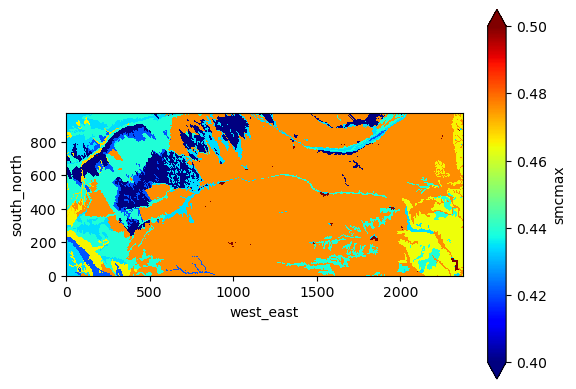

In [48]:
import matplotlib.pyplot as plt

p = ds.smcmax.sel(soil_layers_stag=0).plot(vmin=0.4,vmax=0.5, cmap=plt.cm.jet)
p.axes.set_aspect('equal')

This concludes the lesson on domain definition and initial conditions for WRF-Hydro. 

© UCAR 2020

## 2.6. Switching to wbt2 environment

Then we need to reload the directory tree creation

In [ ]:
Paths.dom_dir

In [52]:
os.chdir("./wrf_hydro_gis_preprocessor/wrfhydro_gis")

In [54]:
os.chdir("./wrf_hydro_nwm_public_derecho/wrf_hydro_gis_preprocessor-master/wrfhydro_gis")

In [ ]:
! pwd

## 3. Building the hydrologic routing grids, aka the "routing stack"

The Build_Routing_Stack.py script is a program to build the full set of hydrologically-processed routing grids and additional data required by WRF-Hydro. This is the main utility for performing WRF-Hydro GIS pre-processing. The required inputs are the domain file (WPS geogrid file), desired routing grid resolution as a function of geogrid resolution, and other options and parameter values. The output will be a "routing stack" zip file with WRF-Hydro domain and parameter files.

• Required Parameters:<br>
&emsp;`-i` -WRF/WPS GEOGRID file (geo_em.d0*.nc)<br>
&emsp;`-d` -High-resolution Elevation raster file (Esri GRID, GeoTIFF, VRT, etc.)<br>
&emsp;`-R` -Regridding Factor – nesting relationship of routing:land surface model grid cells<br>
&emsp;`-t` -Minimum basin area threshold (in routing grid cells)<br>
&emsp;`-o` -Output ZIP File containing all script outputs<br>

• Optional Parameters:<br>
&emsp;`--CSV` -Station Locations location file (.csv)<br>
&emsp;`-b` -Option to mask channel grids not contributing to provided station locations<br>
&emsp;`-r` -Reach based (Muskingum / Muskingum-Cunge) routing option<br>
&emsp;`-l` -Lake Polygons (polygon feature class or .shp)<br>
&emsp;`-O` -OVROUGHRTFAC – Multiplier on Manning's roughness for overland flow. default=1.0<br>
&emsp;`-T` -RETDEPRTFAC – Multiplier on maximum retention depth before flow is routed as overland flow. default=1.0<br>
&emsp;-LKSATFAC – (script global variable) Multiplier on saturated hydraulic conductivity in lateral flow direction. default=1000.0<br>
&emsp;`--starts` -Path to point shapefile or feature class containing channel initiation locations (overrides `-t` parameter)<br>
&emsp;`--gw` -Path to polygon shapefile or feature class containing prescribed groundwater basin locations<br>

#### Request help message from the script
This tool has many different parameters and possible configurations. Using the command line, we can take a look at the different arguments that can be used, if they are required or optional, and what their default values are.

In [56]:
! python Build_Routing_Stack.py -h

Script initiated at Fri Sep 27 13:15:51 2024
usage: Build_Routing_Stack.py [-h] -i IN_GEOGRID [--CSV IN_CSV]
                              [-b BASIN_MASK] [-r RB_ROUTING]
                              [-l IN_RESERVOIRS] -d INDEM [-R CELLSIZE]
                              [-t THRESHOLD] [-o OUT_ZIP_FILE]
                              [-O OVROUGHRTFAC_VAL] [-T RETDEPRTFAC_VAL]
                              [--starts CHANNEL_STARTS] [--gw GW_POLYS]
                              [--mask CH_MASK]

This is a program to perform the full routing-stack GIS pre-processingfor WRF-
Hydro. The inputs will be related to the domain, the desired routing nest
factor, and other options and parameter values. The output will be a routing
stack zip file with WRF-Hydro domain and parameter files.

options:
  -h, --help            show this help message and exit
  -i IN_GEOGRID         Path to WPS geogrid (geo_em.d0*.nc) file [REQUIRED]
  --CSV IN_CSV          Path to input forecast point CSV file [OPTIONAL

In [ ]:
Paths.geo_dir

In [58]:
output_folder = os.path.join(Paths.wps_dir, 'Outputs')

In [ ]:
Paths.dom_dir

In [61]:
import Build_Routing_Stack

# Define script input parameters using python variables
in_geogrid = os.path.join(Paths.dom_dir, 'geo_em.d01.nc')
# lakes = os.path.join(data_folder, 'lake_shapes', 'lakes.shp')
# csv = os.path.join(data_folder, 'forecast_points.csv')
# in_dem = os.path.join(Paths.dom_dir, 'repub_dem2.tif')
in_dem = os.path.join(output_folder, 'HGT_M.tif')
regrid_factor = 1 # Multiplier between routing grid and LSM grid; e.g., 1-km LSM and 250-m routing means a value of 4
routing_cells = 25
# routing_cells = 200
out_zip = os.path.join(output_folder, tag + '.zip')

# Print information to screen for reference
print('Command to run:\n')
print('python Build_Routing_Stack.py \\\n\t -i {0} \\\n\t -d {1} \\\n\t -R {2} \\\n\t -t {3} \\\n\t -o {4}\n'.format(in_geogrid, in_dem, regrid_factor, routing_cells, out_zip))

# Run the script with required parameters
! python Build_Routing_Stack.py -i {in_geogrid} -d {in_dem} -R {regrid_factor} -t {routing_cells} -o {out_zip}

Command to run:

python Build_Routing_Stack.py \
	 -i /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/wrfhydro_cutout/repub_250m_v01/DOMAIN/geo_em.d01.nc \
	 -d /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/wrfhydro_cutout/repub_250m_v01/Outputs/HGT_M.tif \
	 -R 1 \
	 -t 25 \
	 -o /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/wrfhydro_cutout/repub_250m_v01/Outputs/repub_250m_v01.zip

Script initiated at Fri Sep 27 13:15:51 2024
  Parameter values that have not been altered from script default values:
    Using default basin mask setting: False
    Using default reach-based routing setting: False
    Using default OVROUGHRTFAC parameter value: 1.0
    Using default RETDEPRTFAC parameter value: 1.0
  Values that will be used in building this routing stack:
    Input WPS Geogrid file: /glade/work/felfelan/wrf_hydro_nwm_public/soren_bmi/coupled_prepostproc_tutorial/wrfhydro_cutout/repub_2